In [1]:
# compute disc implicit connectives metrics

# for each doc: tanh (num of unique connective types / num of types)
# averaged across docs

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

DISCOURSE_RELS_DIR = Path('/mimer/NOBACKUP/groups/naiss2025-22-1187/coherence-driven-humans/data/res60_v2/')


In [3]:
def normalize_story_id(raw_id):
    # formatting of story id
    s = str(raw_id).replace('story_', '')
    parts = s.split('_')
    if len(parts) >= 2 and parts[0] == 'doc':
        s = parts[1]
    try:
        return int(float(s))
    except (ValueError, TypeError):
        return None

def load_rels_data():
    all_data = []
    for folder in DISCOURSE_RELS_DIR.iterdir():
        if not folder.is_dir():
            continue
        rels_path = folder / "eng.pdtb.gum" / "eng.pdtb.gum_test.rels"
        if not rels_path.exists():
            continue
        # the output of the classifer produced a specific format
        parts = folder.name.split('_')
        model = parts[0]
        prompt = parts[1] if len(parts) > 1 else 'unknown'
        seed = parts[2] if len(parts) > 2 else None
        df = pd.read_csv(rels_path, sep='\t')
        df['model'] = model
        df['prompt'] = prompt
        df['seed'] = seed
        df['source_folder'] = folder.name
        all_data.append(df)
    return pd.concat(all_data, ignore_index=True)

def compute_discourse_diversity(df):
    prediction_col = 'prediction' if 'prediction' in df.columns else 'label'
    results = []
    groups = df.groupby(['model', 'prompt', 'seed', 'doc'], dropna=False)
    for (model, prompt, seed, doc), story_df in groups:
        relations = story_df[prediction_col].tolist()
        n_total = len(relations)
        print(doc, relations, n_total, model, prompt, seed)
        n_none = sum(1 for r in relations if r in ['NONE', 'none', None, ''])
        valid_relations = [r for r in relations if r not in ['NONE', 'none', None, '']]

        if len(valid_relations) == 0:
            diversity_ratio = 0.0
            n_unique = 0
        else:
            n_unique = len(set(valid_relations))
            diversity_ratio = np.tanh(n_unique / len(valid_relations))

        none_rate = (n_none / n_total) if n_total > 0 else 0.0

        results.append({
            'model': model, 'prompt': prompt, 'seed': seed, 'doc': doc,
            'n_unique_relations': n_unique, 'n_total_relations': n_total,
            'n_none_relations': n_none, 'none_rate': none_rate,
            'discourse_diversity': diversity_ratio
        })
    return pd.DataFrame(results)

In [4]:
def prepare_discourse_data(diversity_df):
    # averaging across human seeds
    results = []
    for model in diversity_df['model'].unique():
        for prompt in diversity_df['prompt'].unique():
            subset = diversity_df[(diversity_df['model'] == model) & 
                                  (diversity_df['prompt'] == prompt)]
            if subset.empty:
                continue
            seeds = subset['seed'].dropna().unique()
            if len(seeds) > 1:
                story_avg = subset.groupby('doc').agg({
                    'n_unique_relations': 'mean',
                    'n_total_relations': 'mean',
                    'n_none_relations': 'mean',
                    'none_rate': 'mean',
                    'discourse_diversity': 'mean'
                }).reset_index()
                for _, row in story_avg.iterrows():
                    results.append({
                        'model': model, 'prompt': prompt, 'story_id': normalize_story_id(row['doc']),
                        'n_unique_relations': row['n_unique_relations'],
                        'n_total_relations': row['n_total_relations'],
                        'n_none_relations': row['n_none_relations'],
                        'none_rate': row['none_rate'],
                        'discourse_diversity': row['discourse_diversity']
                    })
            else:
                for _, row in subset.iterrows():
                    results.append({
                        'model': model, 'prompt': prompt, 'story_id': normalize_story_id(row['doc']),
                        'n_unique_relations': row['n_unique_relations'],
                        'n_total_relations': row['n_total_relations'],
                        'n_none_relations': row['n_none_relations'],
                        'none_rate': row['none_rate'],
                        'discourse_diversity': row['discourse_diversity']
                    })
    result = pd.DataFrame(results)
    result['story_id'] = result['story_id'].astype(int)
    return result

In [5]:
df_rels_raw = load_rels_data()
print(df_rels_raw.head())

           doc unit1_toks unit2_toks  \
0  story_13596       1-34      35-62   
1  story_13596      35-62      63-97   
2  story_13596      63-97     98-126   
3  story_13596     98-126    127-160   
4   story_6111       1-45      46-77   

                                           unit1_txt  \
0  Emile slumps over a makeshift table, his head ...   
1  He lifts his head, scanning the table with a w...   
2  His attention shifts to a worn book he picks u...   
3  A closer view reveals his focused gaze tracing...   
4  Three men gather in a dimly lit, shabby room w...   

                                           unit2_txt  \
0  He lifts his head, scanning the table with a w...   
1  His attention shifts to a worn book he picks u...   
2  A closer view reveals his focused gaze tracing...   
3  Finally, he holds a small object near his mout...   
4  Dexter, wearing a red shirt beneath his trench...   

                                              u1_raw  \
0  Emile slumps over a makesh

In [6]:
df_diversity_raw = compute_discourse_diversity(df_rels_raw)
print(df_diversity_raw.head())

story_10408 ['temporal', 'temporal', 'temporal', 'temporal', 'temporal'] 5 claude45 large nan
story_10486 ['temporal', 'temporal', 'temporal', 'temporal', 'temporal'] 5 claude45 large nan
story_10499 ['temporal', 'temporal', 'temporal', 'temporal'] 4 claude45 large nan
story_1111 ['elaboration', 'conjunction', 'temporal', 'elaboration'] 4 claude45 large nan
story_11260 ['elaboration', 'temporal', 'temporal', 'temporal'] 4 claude45 large nan
story_11340 ['temporal', 'temporal', 'temporal', 'temporal'] 4 claude45 large nan
story_11457 ['conjunction', 'conjunction', 'conjunction', 'conjunction'] 4 claude45 large nan
story_11541 ['conjunction', 'temporal', 'temporal', 'temporal'] 4 claude45 large nan
story_11543 ['conjunction', 'temporal', 'temporal', 'elaboration'] 4 claude45 large nan
story_11678 ['conjunction', 'conjunction', 'temporal', 'conjunction'] 4 claude45 large nan
story_11719 ['conjunction', 'temporal', 'contrast', 'temporal'] 4 claude45 large nan
story_1201 ['conjunction', 'co

In [7]:
df_discourse = prepare_discourse_data(df_diversity_raw)
print(df_discourse.head())


      model prompt  story_id  n_unique_relations  n_total_relations  \
0  claude45  large     10408                 1.0                5.0   
1  claude45  large     10486                 1.0                5.0   
2  claude45  large     10499                 1.0                4.0   
3  claude45  large      1111                 3.0                4.0   
4  claude45  large     11260                 2.0                4.0   

   n_none_relations  none_rate  discourse_diversity  
0               0.0        0.0             0.197375  
1               0.0        0.0             0.197375  
2               0.0        0.0             0.244919  
3               0.0        0.0             0.635149  
4               0.0        0.0             0.462117  


In [8]:
discourse_agg = (
    df_discourse.groupby(['model', 'prompt'])
    .agg(
        n_unique_relations=('n_unique_relations', 'mean'),
        n_total_relations=('n_total_relations', 'mean'),
        n_none_relations=('n_none_relations', 'mean'),
        none_rate=('none_rate', 'mean'),
        discourse_diversity_mean=('discourse_diversity', 'mean'),
        discourse_diversity_std=('discourse_diversity', 'std'),
        count=('discourse_diversity', 'count')
    )
    .reset_index()
)

In [9]:
discourse_agg

,model,prompt,n_unique_relations,n_total_relations,n_none_relations,none_rate,discourse_diversity_mean,discourse_diversity_std,count
0,claude45,large,2.100000,4.750000,0.0,0.0,0.418078,0.135300,60
1,claude45,original,2.133333,4.666667,0.0,0.0,0.434063,0.131916,60
2,gpt4o,large,1.800000,4.716667,0.0,0.0,0.368886,0.134525,60
3,gpt4o,original,2.016667,4.600000,0.0,0.0,0.412273,0.149802,60
4,human,large,2.066667,4.700000,0.0,0.0,0.406794,0.116079,60
5,human,original,2.400000,4.783333,0.0,0.0,0.462533,0.145981,60
6,internvl3,large,1.800000,5.116667,0.0,0.0,0.343011,0.145236,60
7,internvl3,original,1.833333,4.950000,0.0,0.0,0.352538,0.149605,60
8,llama4scout,large,1.950000,5.300000,0.0,0.0,0.358464,0.128093,60
9,llama4scout,original,1.916667,4.650000,0.0,0.0,0.391748,0.151668,60


In [ ]:
# humans have the highest diversity in implicit discourse relation types, especially with the original prompt
# so they use wide range of types
# intern and llama have lowest diversity, so they tend to repeat types
# gpt and qwen are sort of in the middle
# claude is close to humans

# what drives diversity score? is it because some stories are longer, like, more n_total_relations?
# all agents produce relatively the same number of descriptions (5-6)
# but humans tend to pack in more unique relation types (2.4 vs 1.7 - 2.1), the higher diversity score for humans than comes from using a wider variety of types rather than having longer stories (with more descriptions).

In [10]:
# n_total_relations per story and summary by model/prompt

n_rels_story = df_discourse[['model', 'prompt', 'story_id', 'n_total_relations']].copy()

n_rels_summary = (
    n_rels_story.groupby(['model', 'prompt'])['n_total_relations']
    .agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    .reset_index()
)

print('n_total_relations summary by model/prompt:')
n_rels_summary


n_total_relations summary by model/prompt:


,model,prompt,count,mean,std,min,median,max
0,claude45,large,60,4.750000,1.216065,4.0,4.0,8.0
1,claude45,original,60,4.666667,1.188457,2.0,4.0,8.0
2,gpt4o,large,60,4.716667,1.194502,4.0,4.0,8.0
3,gpt4o,original,60,4.600000,0.994902,4.0,4.0,8.0
4,human,large,60,4.700000,1.155842,4.0,4.0,8.0
5,human,original,60,4.783333,1.366570,4.0,4.0,9.0
6,internvl3,large,60,5.116667,1.530389,1.0,5.0,10.0
7,internvl3,original,60,4.950000,1.111191,3.0,5.0,8.0
8,llama4scout,large,60,5.300000,1.690452,3.0,5.0,10.0
9,llama4scout,original,60,4.650000,1.232677,1.0,4.0,9.0


In [11]:
# num total relations: how many implicit discourse relation types the story contains
# num of unique relations: how many different unique discourse relation types are identified

# discourse diversity: tanh (num total relations / n unique relations)

# squashed between 0 and 1, there are no NONE relations, meaning that every pair of sentences has some relation, according to the classifier
# values near 1: high type diversity, uses a wider mix of implicit relation types
# values near 0: low diversity, repeats the same few relation types

# reporting together with n_total relations is important, because high diversity with low totals could show high relation type variety achieved in shorter text (e.g. human original).


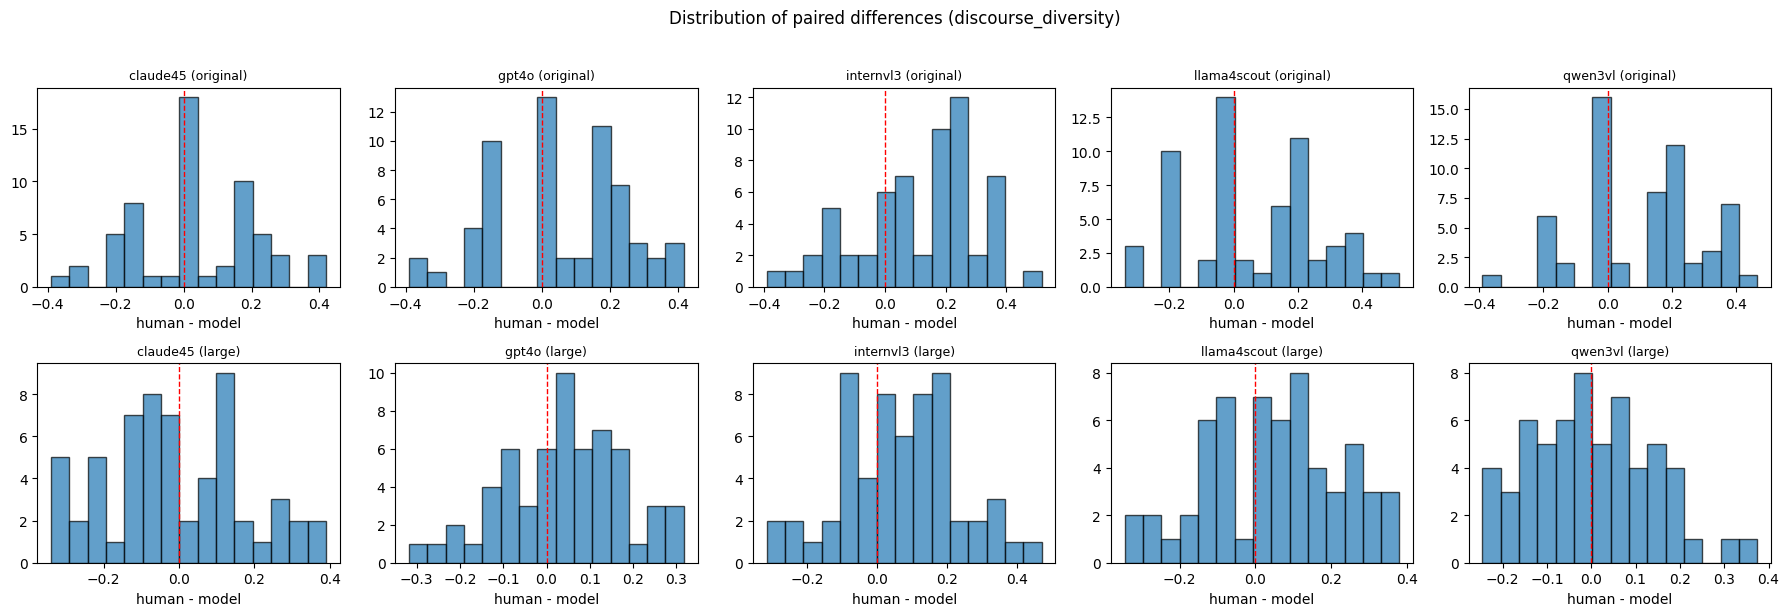

In [12]:
# visualising the distribution of diversity differences between humans and each model
# check shape of paired differences before/alongside t-tests

import matplotlib.pyplot as plt

MODELS = ['human', 'claude45', 'gpt4o', 'internvl3', 'llama4scout', 'qwen3vl']
PROMPTS = ['original', 'large']

fig, axes = plt.subplots(len(PROMPTS), len(MODELS) - 1, figsize=(18, 6), squeeze=False)

for i, prompt in enumerate(PROMPTS):
    df_human = df_discourse[(df_discourse['model'] == 'human') & (df_discourse['prompt'] == prompt)].set_index('story_id')
    col = 0
    for model in MODELS:
        if model == 'human':
            continue
        df_model = df_discourse[(df_discourse['model'] == model) & (df_discourse['prompt'] == prompt)].set_index('story_id')
        common_ids = df_human.index.intersection(df_model.index)

        diffs = df_human.loc[common_ids, 'discourse_diversity'].values - df_model.loc[common_ids, 'discourse_diversity'].values

        ax = axes[i][col]
        ax.hist(diffs, bins=15, edgecolor='black', alpha=0.7)
        ax.axvline(0, color='red', linestyle='--', linewidth=1)
        ax.set_title(f"{model} ({prompt})", fontsize=9)
        ax.set_xlabel('human - model')
        col += 1

plt.suptitle('Distribution of paired differences (discourse_diversity)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
from scipy.stats import ttest_rel

MODELS = ['human', 'claude45', 'gpt4o', 'internvl3', 'llama4scout', 'qwen3vl']
PROMPTS = ['original', 'large']

# Paired t-test per prompt, paired by story_id
# Models vs Humans
# do VLMs produce stories with different implicit discourse diversity than humans?
# do VLMs vary implicit relation types differently than humans?

model_vs_human_results = []
for prompt in PROMPTS:
    print(f"--- Prompt: {prompt} ---")
    df_human = df_discourse[(df_discourse['model'] == 'human') & (df_discourse['prompt'] == prompt)].set_index('story_id')

    for model in MODELS:
        if model == 'human':
            continue
        df_model = df_discourse[(df_discourse['model'] == model) & (df_discourse['prompt'] == prompt)].set_index('story_id')

        common_ids = df_human.index.intersection(df_model.index)
        if len(common_ids) == 0:
            print(f"  {model}: no common story_ids")
            continue

        human_vals = df_human.loc[common_ids, 'discourse_diversity'].values
        model_vals = df_model.loc[common_ids, 'discourse_diversity'].values

        stat, p = ttest_rel(human_vals, model_vals)
        direction = "model > human" if np.mean(model_vals) > np.mean(human_vals) else "model < human"
        print(f"  {model:15s}  t={stat:.3f}  p={p:.4f}  n={len(common_ids)}  ({direction})")
    print()


--- Prompt: original ---
  claude45         t=1.194  p=0.2373  n=60  (model < human)
  gpt4o            t=1.948  p=0.0561  n=60  (model < human)
  internvl3        t=4.327  p=0.0001  n=60  (model < human)
  llama4scout      t=2.633  p=0.0108  n=60  (model < human)
  qwen3vl          t=4.500  p=0.0000  n=60  (model < human)

--- Prompt: large ---
  claude45         t=-0.469  p=0.6407  n=60  (model > human)
  gpt4o            t=2.100  p=0.0400  n=60  (model < human)
  internvl3        t=3.015  p=0.0038  n=60  (model < human)
  llama4scout      t=2.071  p=0.0428  n=60  (model < human)
  qwen3vl          t=0.315  p=0.7539  n=60  (model < human)



In [ ]:
# overall, humans and models do not show a consistent picture on differences in diversity
# but the general trend is that humans often have higher diversity than models (compared to intern and qwen)

In [14]:
# Paired t-test per prompt, paired by story_id
# Original vs Large prompt
# do VLMs differ in their implicit connective diversity across prompts?

for model in MODELS:
    df_orig = df_discourse[(df_discourse['model'] == model) & (df_discourse['prompt'] == 'original')].set_index('story_id')
    df_large = df_discourse[(df_discourse['model'] == model) & (df_discourse['prompt'] == 'large')].set_index('story_id')
    
    common_ids = df_orig.index.intersection(df_large.index)
    if len(common_ids) == 0:
        print(f"  {model}: no common story_ids")
        continue
    
    orig_vals = df_orig.loc[common_ids, 'discourse_diversity'].values
    large_vals = df_large.loc[common_ids, 'discourse_diversity'].values
    
    stat, p = ttest_rel(orig_vals, large_vals)
    direction = "large > original" if np.mean(large_vals) > np.mean(orig_vals) else "large < original"
    print(f"  {model:15s}  t={stat:.3f}  p={p:.4f}  n={len(common_ids)}  ({direction})")

  human            t=2.229  p=0.0296  n=60  (large < original)
  claude45         t=0.778  p=0.4396  n=60  (large < original)
  gpt4o            t=2.191  p=0.0324  n=60  (large < original)
  internvl3        t=0.404  p=0.6877  n=60  (large < original)
  llama4scout      t=1.486  p=0.1426  n=60  (large < original)
  qwen3vl          t=-2.385  p=0.0203  n=60  (large > original)


In [15]:
# similar behaviour here
# between the two prompts, humans do change behaviour
# not all models do, qwen goes in a different direction even

In [17]:
discdata_path = Path('./analysis_data/implicit_connectives/')
discdata_path.mkdir(parents=True, exist_ok=True)

df_rels_raw.to_csv(discdata_path / 'rels_raw.csv', index=False)
df_diversity_raw.to_csv(discdata_path / 'discourse_diversity_raw.csv', index=False)
df_discourse.to_csv(discdata_path / 'discourse_metrics.csv', index=False)
discourse_agg.to_csv(discdata_path / 'discourse_metrics_agg.csv', index=False)
